# Predictive ML Project: NYC January Average High Temperature

**Author:** Danilo Traconis  
**Repo:** https://github.com/traconisdanilo/datafun-07-ml  
**Date:** February 2026  

This notebook follows the guided projects from the textbook (10.16 and 15.4) to build linear regression models and predict NYC’s average January high temperature for **2024**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Part 1 — Chart a Straight Line

In [2]:
temps = pd.DataFrame({"Celsius": [-40, -10, 0, 8, 15, 22, 38], "Fahrenheit": [-40, 14, 32, 46, 59, 72, 100]})
temps

,Celsius,Fahrenheit
0,-40,-40
1,-10,14
2,0,32
3,8,46
4,15,59
5,22,72
6,38,100


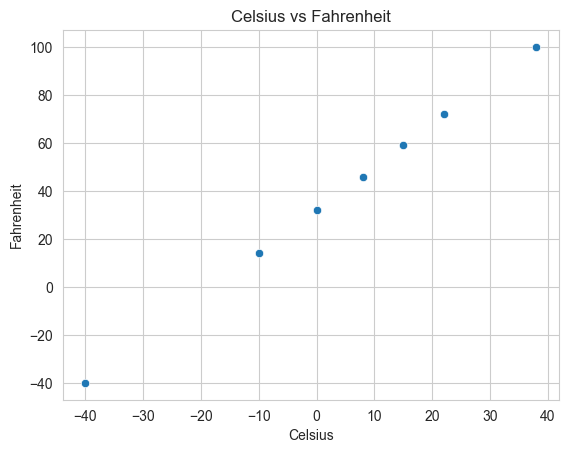

In [3]:
sns.set_style("whitegrid")
sns.scatterplot(data=temps, x="Celsius", y="Fahrenheit")
plt.title("Celsius vs Fahrenheit")
plt.show()

## Part 2 — Prediction (SciPy linregress)
### Section 1 — Data Acquisition

In [4]:
nyc_df = pd.read_csv("../data/ave_hi_nyc_jan_1895-2018.csv")
nyc_df.head()

,Date,Value,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9
3,189801,39.6,2.2
4,189901,36.4,-1.0


### Section 2 — Data Inspection

In [5]:
print(nyc_df.head())
print(nyc_df.tail())
print(nyc_df.dtypes)

     Date  Value  Anomaly
0  189501   34.2     -3.2
1  189601   34.7     -2.7
2  189701   35.5     -1.9
3  189801   39.6      2.2
4  189901   36.4     -1.0
       Date  Value  Anomaly
119  201401   35.5     -1.9
120  201501   36.1     -1.3
121  201601   40.8      3.4
122  201701   42.8      5.4
123  201801   38.7      1.3
Date         int64
Value      float64
Anomaly    float64
dtype: object


### Section 3 — Data Cleaning

In [6]:
# Keep only the first two columns (Date + Temperature)
nyc_df = nyc_df.iloc[:, :2].copy()

# Rename columns
nyc_df.columns = ["Date", "Temperature"]

# Convert data types
nyc_df["Date"] = nyc_df["Date"].astype(int)
nyc_df["Temperature"] = nyc_df["Temperature"].astype(float)

nyc_df.head()

,Date,Temperature
0,189501,34.2
1,189601,34.7
2,189701,35.5
3,189801,39.6
4,189901,36.4


### Section 4 — Descriptive Statistics

In [7]:
pd.set_option("display.precision", 2)
nyc_df.describe()

,Date,Temperature
count,124.00,124.00
mean,195651.00,37.60
std,3593.98,4.54
min,189501.00,26.10
25%,192576.00,34.58
50%,195651.00,37.60
75%,198726.00,40.60
max,201801.00,47.60


### Section 5 — Build the Model

In [8]:
from scipy import stats

linear_regression = stats.linregress(
    x=nyc_df["Date"],
    y=nyc_df["Temperature"]
)

linear_regression

LinregressResult(slope=np.float64(0.00014771361132966167), intercept=np.float64(8.694845520062952), rvalue=np.float64(0.11693766700752921), pvalue=np.float64(0.19586679787456185), stderr=np.float64(0.00011357855112603289), intercept_stderr=np.float64(22.225475726342946))

### Section 6 — Predict (2024)

In [9]:
pred_2024_part2 = linear_regression.slope * 2024 + linear_regression.intercept
print(f"Part 2 prediction for 2024: {pred_2024_part2:.2f} °F")

Part 2 prediction for 2024: 8.99 °F


### Section 7 — Visualization

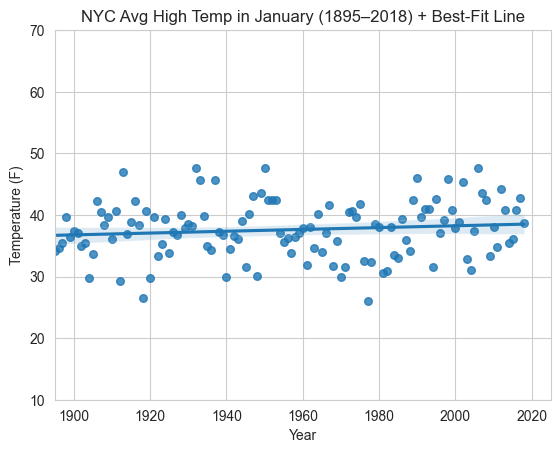

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

nyc_df["Date"] = (nyc_df["Date"] // 100).astype(int)

ax = sns.regplot(
    data=nyc_df,
    x="Date",
    y="Temperature",
    scatter_kws={"s": 30}
)

ax.set_xlim(1895, 2025)
ax.set_ylim(10, 70)
ax.set_title("NYC Avg High Temp in January (1895–2018) + Best-Fit Line")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (F)")

plt.show()

## Part 3 — Prediction (scikit-learn)
### Section 1 — Build the Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# sklearn requires X to be 2D
X = nyc_df[["Date"]]
y = nyc_df["Temperature"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

model.coef_, model.intercept_

(array([0.01939167]), np.float64(-0.30779820252656975))

### Section 2 — Test the Model

In [12]:
predicted = model.predict(X_test)

result_df = pd.DataFrame({
    "predicted": predicted,
    "expected": y_test
}).sort_index()

result_df.head()

,predicted,expected
0,36.44,34.2
2,36.48,35.5
6,36.56,37.0
9,36.61,29.8
15,36.73,36.1


### Section 3 — Predict (2024)

In [13]:
linear_regression = stats.linregress(
    x=nyc_df["Date"],
    y=nyc_df["Temperature"]
)

pred_2024_part2 = linear_regression.slope * 2024 + linear_regression.intercept

print(f"Part 2 prediction for 2024: {pred_2024_part2:.2f} °F")

Part 2 prediction for 2024: 38.59 °F


### Section 4 — Visualization

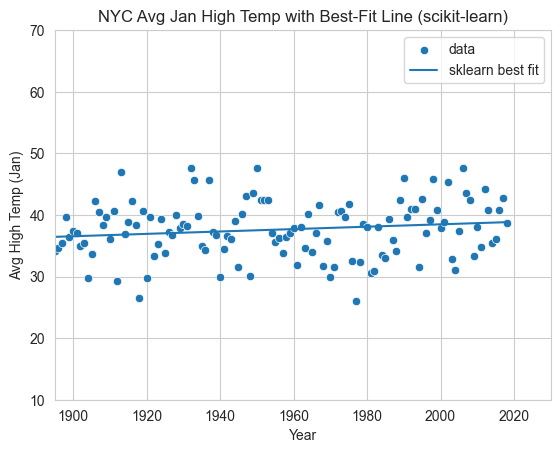

In [14]:
sns.scatterplot(x=nyc_df["Date"], y=nyc_df["Temperature"], label="data")
sns.lineplot(x=nyc_df["Date"], y=model.predict(X), label="sklearn best fit")
plt.title("NYC Avg Jan High Temp with Best-Fit Line (scikit-learn)")
plt.xlabel("Year")
plt.ylabel("Avg High Temp (Jan)")
plt.xlim(1895, 2030)
plt.ylim(10, 70)
plt.show()

## Part 4 — Insights

Both the SciPy and scikit-learn approaches produced very similar predictions for 2024.

- Part 2 (SciPy): 38.59 °F  
- Part 3 (scikit-learn): 38.94 °F  

The results are close because both methods are modeling the same linear relationship in the data. 

The scikit-learn method feels more realistic for machine learning because it includes splitting the data into training and testing sets, which helps evaluate how well the model performs.